# AID843 – A2: Temporal Analysis
## World Cup 2018 vs UEFA Euro 2016 – Tournament Comparison
**Tasks:** Preprocessing → Decomposition → Autocorrelation & Stationarity → ARIMA + Linear Regression

---
## BLOCK 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

print('All imports successful')


All imports successful


---
## BLOCK 2: Load Data

In [2]:
TOURNAMENTS = {
    'World_Cup'  : ('events_World_Cup.csv',             'matches_World_Cup.csv'),
    'Euro_2016'  : ('events_European_Championship.csv', 'matches_European_Championship.csv'),
}

COLORS = {'World_Cup': 'steelblue', 'Euro_2016': 'crimson'}

ROUND_LABELS = {0: 'Group', 1: 'Round of 16', 2: 'QF/SF', 3: 'Final'}

def load_tournament(events_file, matches_file, name):
    ev = pd.read_csv(events_file)
    mt = pd.read_csv(matches_file)
    mt = mt[['wyId','dateutc','gameweek','team1.score','team2.score']].copy()
    mt.rename(columns={'wyId':'matchId'}, inplace=True)
    mt['date'] = pd.to_datetime(mt['dateutc'], utc=True).dt.tz_localize(None)
    mt['total_goals'] = mt['team1.score'] + mt['team2.score']
    df = ev.merge(mt[['matchId','date','gameweek','total_goals']], on='matchId', how='left')
    df['tournament'] = name
    return df, mt

all_events = {}
all_matches = {}

for name, (ev_file, mt_file) in TOURNAMENTS.items():
    df, mt = load_tournament(ev_file, mt_file, name)
    all_events[name] = df
    all_matches[name] = mt
    print(f'{name:12s}: {len(df):>7,} events | {len(mt):>2} matches')
    print(f'  Date range : {mt["date"].min().date()} to {mt["date"].max().date()}')
    print(f'  Rounds     : {sorted(mt["gameweek"].unique())}')
    print()


World_Cup   : 101,756 events | 64 matches
  Date range : 2018-06-14 to 2018-07-15
  Rounds     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Euro_2016   :  78,125 events | 51 matches
  Date range : 2016-06-10 to 2016-07-10
  Rounds     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]



---
## BLOCK 3: Build Time Series
Since tournaments have only 4 rounds (0-3), we use **match-level series** (one value per match) as the primary time series — more granular and meaningful than 4-point round series.

In [3]:
def build_match_series(name):
    """One row per match: shots, passes, duels, goals — sorted by date."""
    df = all_events[name]
    shots  = df[df['eventName']=='Shot'].groupby('matchId').size().rename('shots')
    passes = df[df['eventName']=='Pass'].groupby('matchId').size().rename('passes')
    duels  = df[df['eventName']=='Duel'].groupby('matchId').size().rename('duels')
    freeKicks = df[df['eventName']=='Free Kick'].groupby('matchId').size().rename('free_kicks')
    mt = all_matches[name][['matchId','date','gameweek','total_goals']].copy()
    mt = mt.join(shots, on='matchId').join(passes, on='matchId')
    mt = mt.join(duels, on='matchId').join(freeKicks, on='matchId')
    mt = mt.sort_values('date').reset_index(drop=True)
    mt[['shots','passes','duels','free_kicks']] = mt[['shots','passes','duels','free_kicks']].fillna(0)
    mt['match_idx'] = range(len(mt))
    return mt

def build_round_series(name, event_type='Shot'):
    """Shots/events per tournament round."""
    df = all_events[name]
    sub = df[df['eventName'] == event_type]
    ts = sub.groupby('gameweek').size().reset_index(name='count')
    ts = ts.sort_values('gameweek').reset_index(drop=True)
    ts['round_label'] = ts['gameweek'].map(ROUND_LABELS)
    return ts

def build_within_match_series(name):
    """Events aggregated into 5-minute bins across all matches."""
    df = all_events[name]
    sub = df[df['eventSec'].notna() & (df['eventSec'] >= 0)].copy()
    sub['min_bin'] = ((sub['eventSec'] / 60).clip(0, 95).astype(int) // 5) * 5
    return sub.groupby('min_bin').size().reset_index(name='count')

# Build all series
match_series = {name: build_match_series(name) for name in TOURNAMENTS}
round_series = {name: build_round_series(name) for name in TOURNAMENTS}
within_series = {name: build_within_match_series(name) for name in TOURNAMENTS}

print('Match series preview – World Cup:')
print(match_series['World_Cup'][['date','gameweek','shots','passes','total_goals']].head(8))


Match series preview – World Cup:
                 date  gameweek  shots  passes  total_goals
0 2018-06-14 15:00:00         1     18     827            5
1 2018-06-15 12:00:00         1     18    1000            1
2 2018-06-15 15:00:00         1     18     630            1
3 2018-06-15 18:00:00         1     16    1084            6
4 2018-06-16 10:00:00         1     10     917            3
5 2018-06-16 13:00:00         1     30     927            2
6 2018-06-16 16:00:00         1     24     726            1
7 2018-06-16 19:00:00         1     21     829            2


---
## BLOCK 4: Exploratory Temporal Visualizations

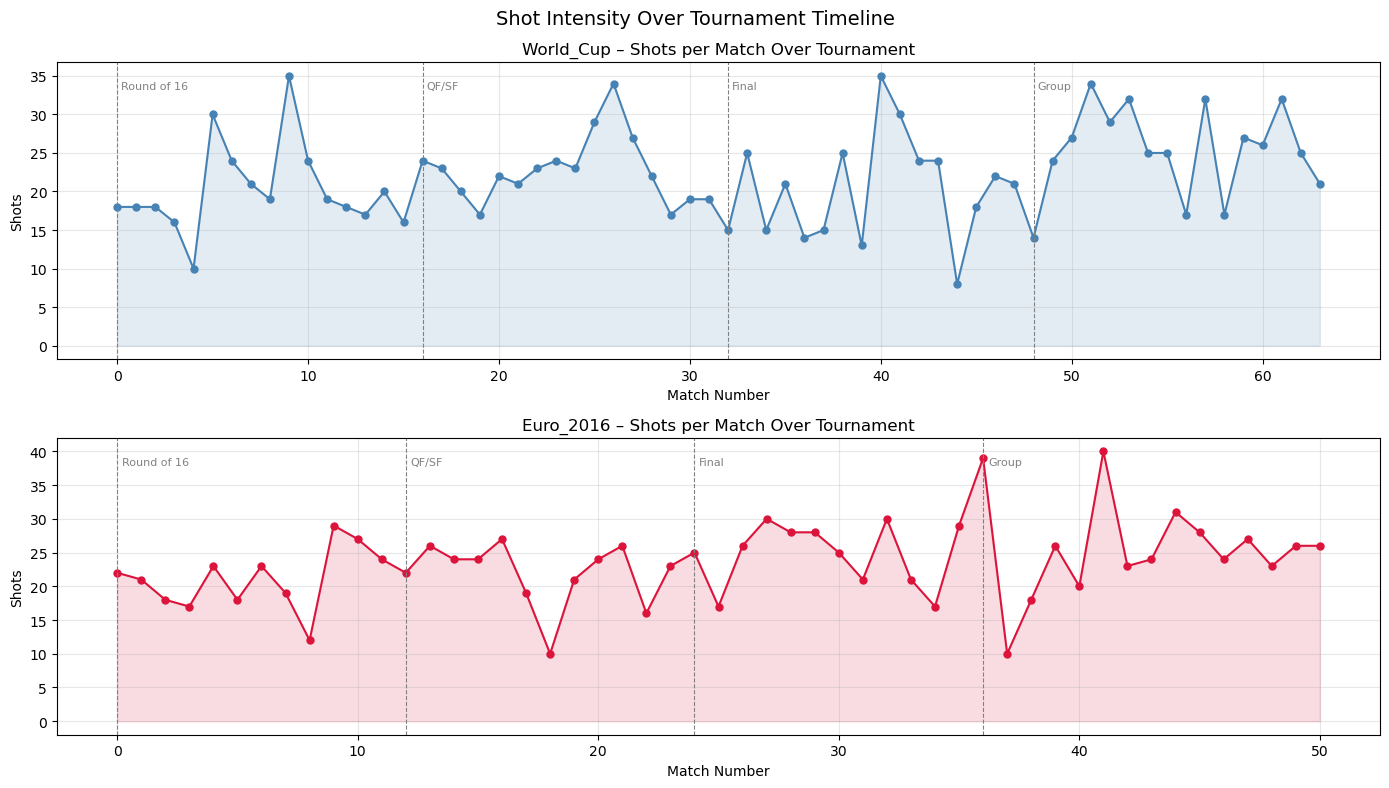

In [4]:
# ── 4a: Shots per match over tournament timeline ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, name in zip(axes, TOURNAMENTS.keys()):
    ms = match_series[name]
    ax.plot(ms['match_idx'], ms['shots'], marker='o', markersize=5,
            linewidth=1.5, color=COLORS[name], label='Shots/match')
    ax.fill_between(ms['match_idx'], ms['shots'], alpha=0.15, color=COLORS[name])
    # Add round boundary lines
    for rnd in ms['gameweek'].unique():
        first_idx = ms[ms['gameweek']==rnd]['match_idx'].iloc[0]
        ax.axvline(first_idx, color='gray', linestyle='--', linewidth=0.8,
                   label=ROUND_LABELS.get(rnd,'') if first_idx==ms[ms['gameweek']==rnd]['match_idx'].iloc[0] else '')
        ax.text(first_idx+0.2, ms['shots'].max()*0.95,
                ROUND_LABELS.get(rnd,''), fontsize=8, color='gray')
    ax.set_title(f'{name} – Shots per Match Over Tournament', fontsize=12)
    ax.set_xlabel('Match Number')
    ax.set_ylabel('Shots')
    ax.grid(alpha=0.3)
plt.suptitle('Shot Intensity Over Tournament Timeline', fontsize=14)
plt.tight_layout()
plt.show()


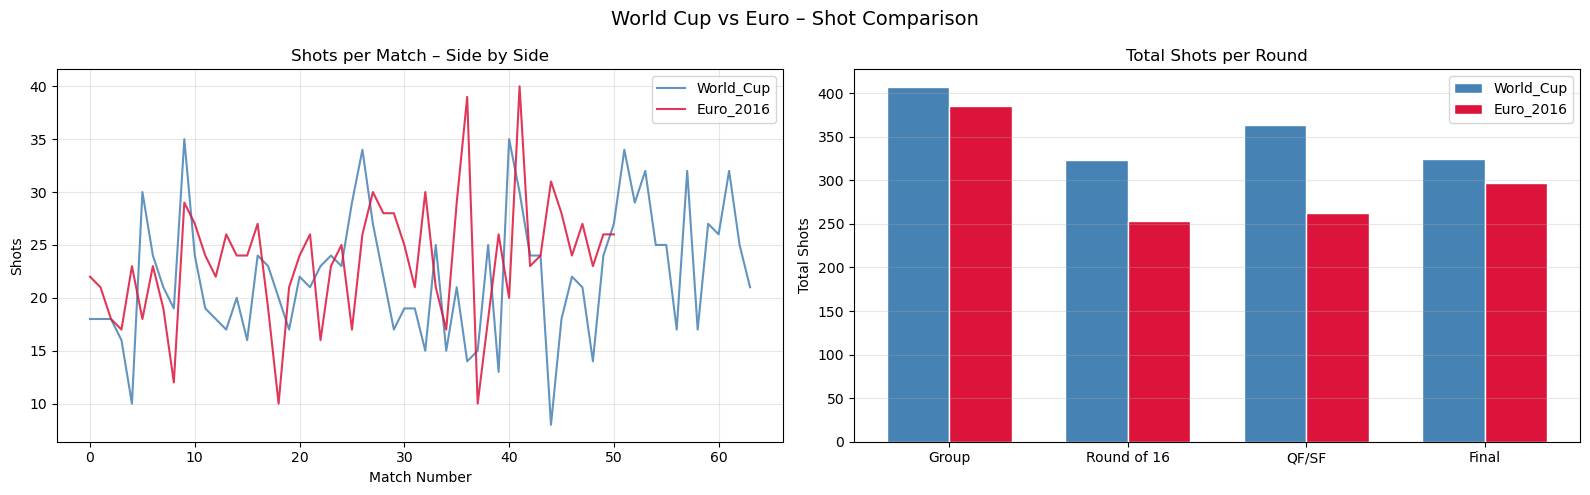

In [5]:
# ── 4b: Direct overlay comparison – shots per match ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overlay on same axis (normalised by match index)
for name in TOURNAMENTS:
    ms = match_series[name]
    axes[0].plot(ms['match_idx'], ms['shots'],
                 color=COLORS[name], linewidth=1.5, label=name, alpha=0.85)
axes[0].set_title('Shots per Match – Side by Side', fontsize=12)
axes[0].set_xlabel('Match Number')
axes[0].set_ylabel('Shots')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Shots per round (bar chart)
x = np.arange(len(ROUND_LABELS))
width = 0.35
for i, name in enumerate(TOURNAMENTS):
    rs = build_round_series(name)
    axes[1].bar(x + i*width, rs['count'], width,
                label=name, color=COLORS[name], edgecolor='white')
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(list(ROUND_LABELS.values()))
axes[1].set_title('Total Shots per Round', fontsize=12)
axes[1].set_ylabel('Total Shots')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('World Cup vs Euro – Shot Comparison', fontsize=14)
plt.tight_layout()
plt.show()


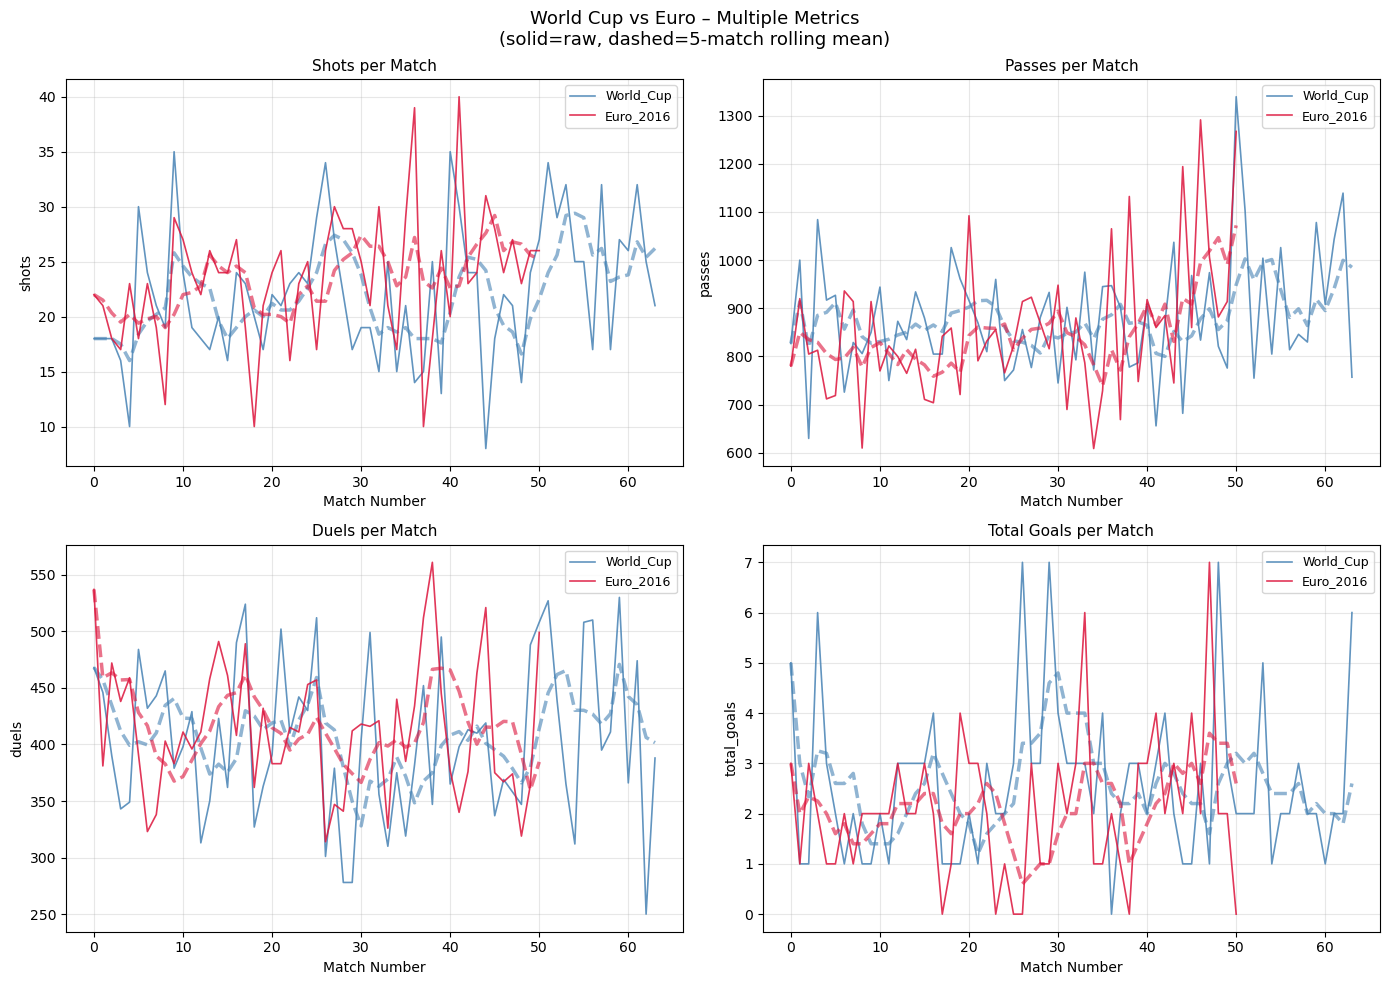

In [6]:
# ── 4c: Multiple metrics comparison ──────────────────────────────────────────
metrics = ['shots', 'passes', 'duels', 'total_goals']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for name in TOURNAMENTS:
        ms = match_series[name]
        ax.plot(ms['match_idx'], ms[metric],
                color=COLORS[name], linewidth=1.2, label=name, alpha=0.85)
        # Rolling mean
        roll = ms[metric].rolling(5, min_periods=1).mean()
        ax.plot(ms['match_idx'], roll,
                color=COLORS[name], linewidth=2.5, linestyle='--', alpha=0.6)
    ax.set_title(f'{metric.replace("_"," ").title()} per Match', fontsize=11)
    ax.set_xlabel('Match Number')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('World Cup vs Euro – Multiple Metrics\n(solid=raw, dashed=5-match rolling mean)', fontsize=13)
plt.tight_layout()
plt.show()


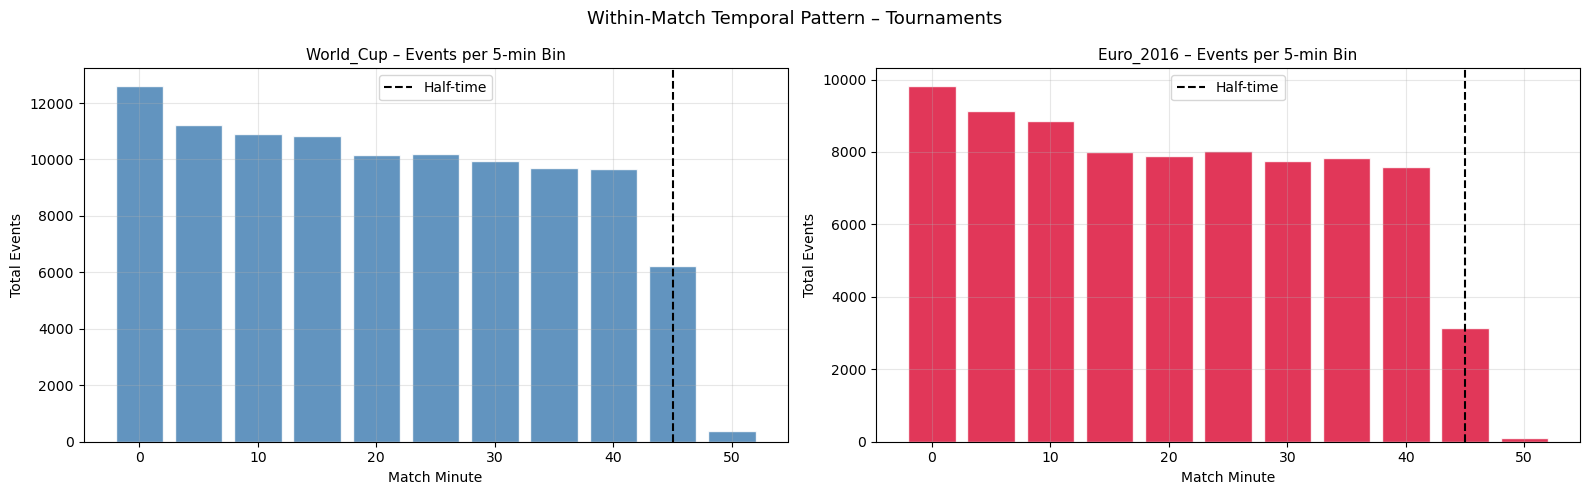

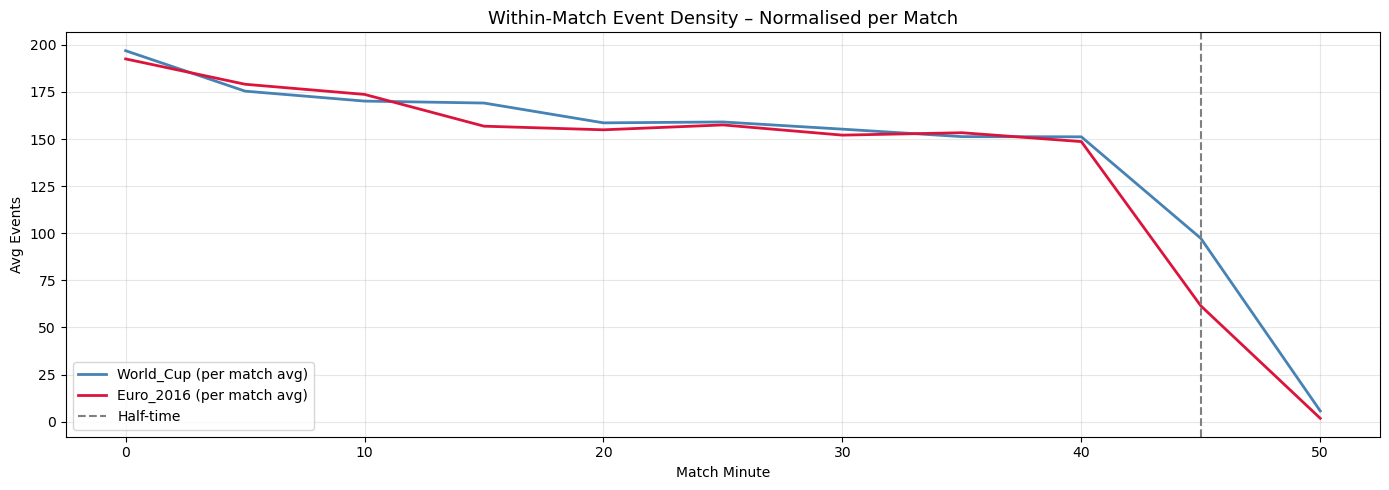

In [7]:
# ── 4d: Within-match event distribution comparison ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, name in zip(axes, TOURNAMENTS.keys()):
    wm = within_series[name]
    ax.bar(wm['min_bin'], wm['count'], width=4,
           color=COLORS[name], edgecolor='white', alpha=0.85)
    ax.axvline(45, color='black', linestyle='--', linewidth=1.5, label='Half-time')
    ax.set_title(f'{name} – Events per 5-min Bin', fontsize=11)
    ax.set_xlabel('Match Minute')
    ax.set_ylabel('Total Events')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Within-Match Temporal Pattern – Tournaments', fontsize=13)
plt.tight_layout()
plt.show()

# Overlay
plt.figure(figsize=(14, 5))
for name in TOURNAMENTS:
    wm = within_series[name]
    # Normalize by number of matches for fair comparison
    n_matches = len(all_matches[name])
    plt.plot(wm['min_bin'], wm['count']/n_matches,
             color=COLORS[name], linewidth=2, label=f'{name} (per match avg)')
plt.axvline(45, color='gray', linestyle='--', label='Half-time')
plt.title('Within-Match Event Density – Normalised per Match', fontsize=13)
plt.xlabel('Match Minute')
plt.ylabel('Avg Events')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


=== Descriptive Statistics Comparison ===

World_Cup (64 matches):
       shots   passes   duels  total_goals
count  64.00    64.00   64.00        64.00
mean   22.17   882.11  405.11         2.59
std     6.09   124.47   69.45         1.57
min     8.00   630.00  250.00         0.00
25%    18.00   802.00  357.50         1.75
50%    22.00   870.50  398.00         2.00
75%    25.00   950.25  455.25         3.00
max    35.00  1339.00  530.00         7.00

Euro_2016 (51 matches):
       shots   passes   duels  total_goals
count  51.00    51.00   51.00        51.00
mean   23.47   856.73  413.59         2.08
std     5.85   147.78   58.34         1.41
min    10.00   609.00  314.00         0.00
25%    20.50   765.50  375.50         1.00
50%    24.00   832.00  411.00         2.00
75%    26.50   914.00  455.00         3.00
max    40.00  1291.00  561.00         7.00


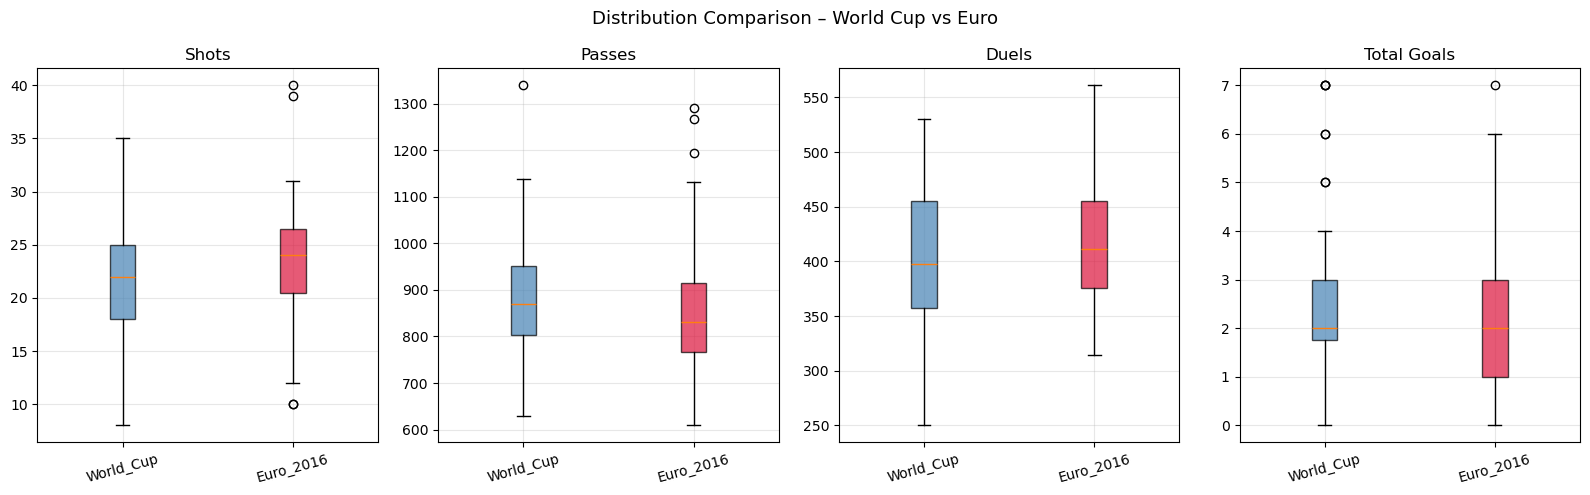

In [8]:
# ── 4e: Summary statistics comparison ────────────────────────────────────────
print('=== Descriptive Statistics Comparison ===')
for name in TOURNAMENTS:
    ms = match_series[name]
    print(f'\n{name} ({len(ms)} matches):')
    print(ms[['shots','passes','duels','total_goals']].describe().round(2).to_string())

# Side-by-side boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, metric in zip(axes, ['shots','passes','duels','total_goals']):
    data = [match_series[name][metric].values for name in TOURNAMENTS]
    bp = ax.boxplot(data, labels=list(TOURNAMENTS.keys()),
                    patch_artist=True, notch=False)
    for patch, name in zip(bp['boxes'], TOURNAMENTS.keys()):
        patch.set_facecolor(COLORS[name])
        patch.set_alpha(0.7)
    ax.set_title(metric.replace('_',' ').title())
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Distribution Comparison – World Cup vs Euro', fontsize=13)
plt.tight_layout()
plt.show()


---
## BLOCK 5: Task 1 – Preprocessing
### Decomposition, Detrending, Deseasonalization
> We use **match-level shots** as the primary time series (64 points for WC, 51 for Euro).

In [9]:
# ── 5a: Extract primary series ────────────────────────────────────────────────
series = {name: match_series[name]['shots'].values for name in TOURNAMENTS}

for name, y in series.items():
    print(f'{name}: length={len(y)}, mean={y.mean():.1f}, std={y.std():.1f}, min={y.min():.0f}, max={y.max():.0f}')


World_Cup: length=64, mean=22.2, std=6.0, min=8, max=35
Euro_2016: length=51, mean=23.5, std=5.8, min=10, max=40


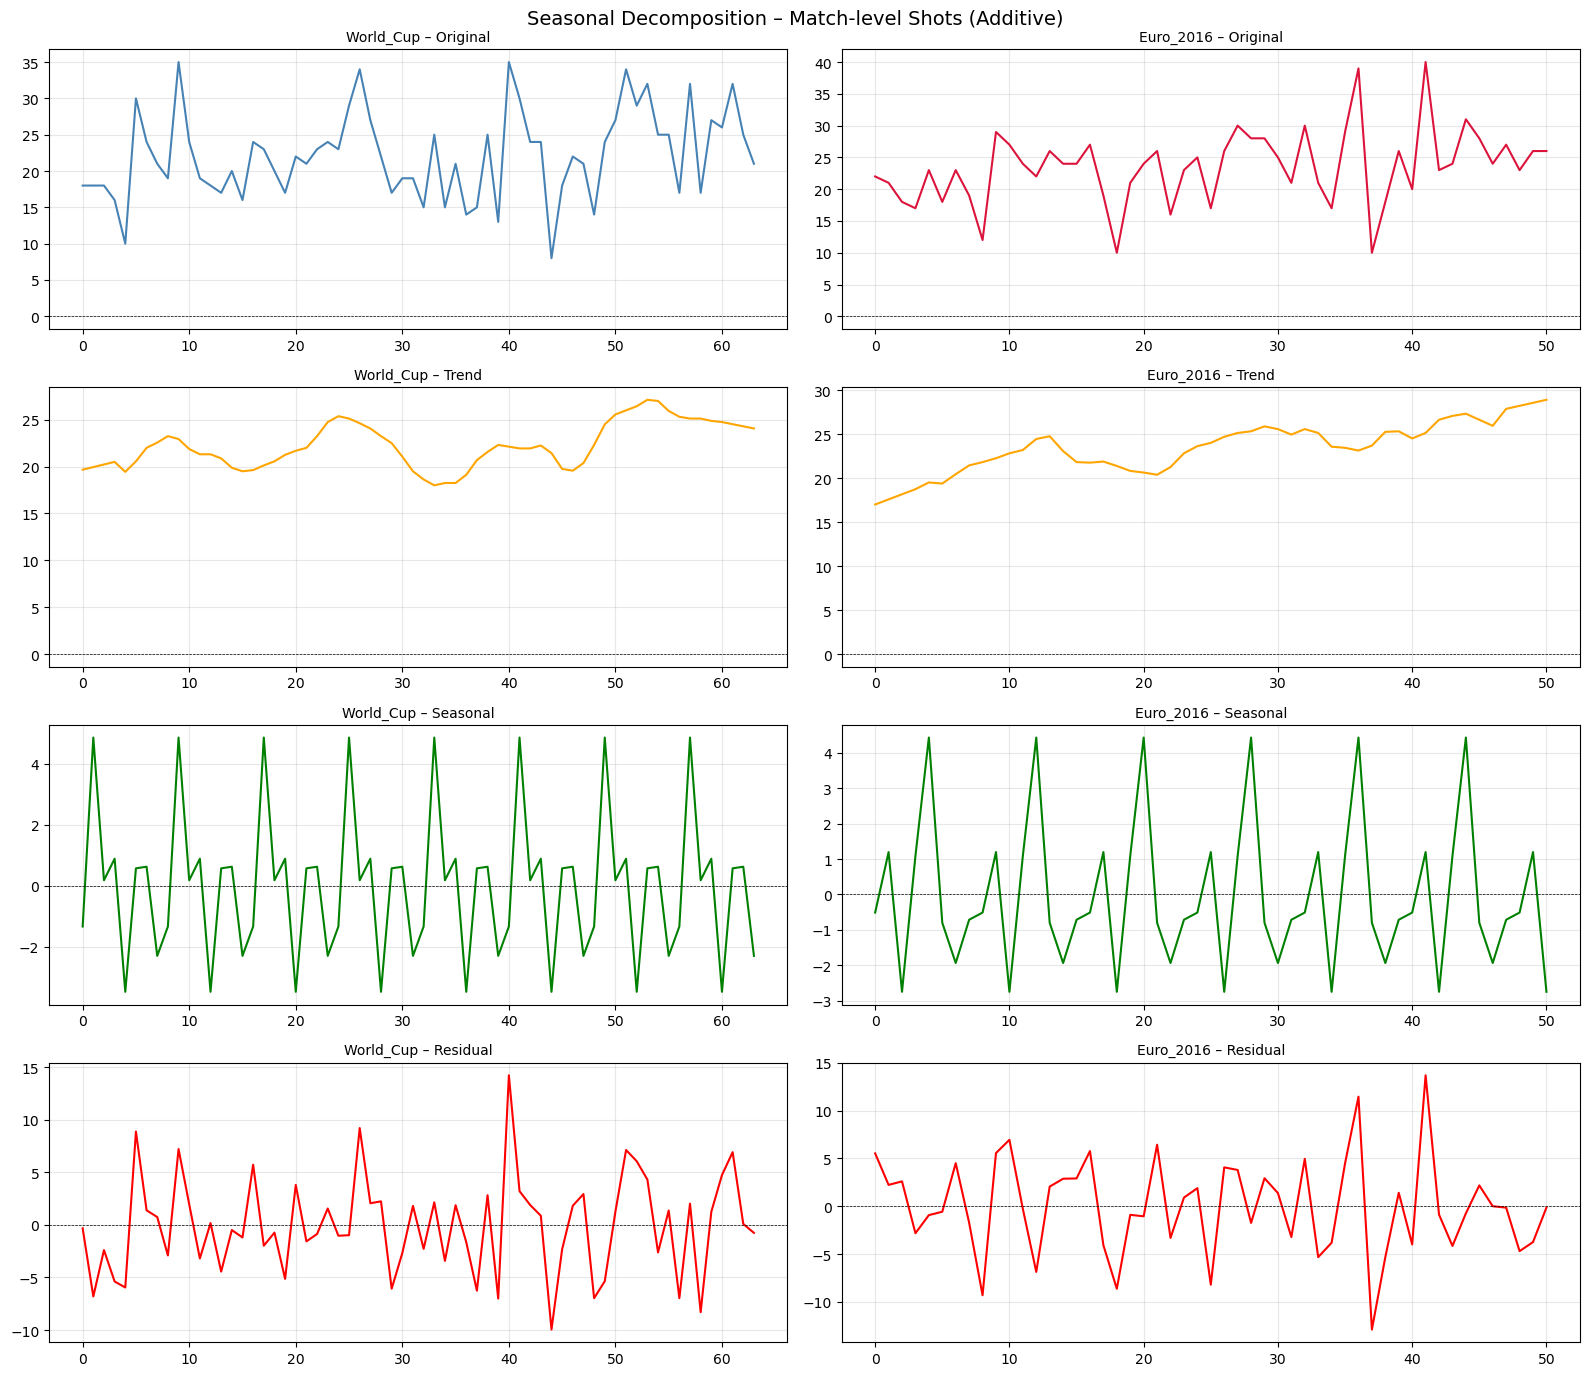

In [10]:
# ── 5b: Seasonal decomposition ────────────────────────────────────────────────
# period=8 = roughly group stage cycle (8 group matches per group day)
fig, big_axes = plt.subplots(4, 2, figsize=(16, 14))
component_names = ['Original', 'Trend', 'Seasonal', 'Residual']

decomps = {}
for col, name in enumerate(TOURNAMENTS.keys()):
    y = series[name]
    y_pos = np.where(y == 0, 0.1, y.astype(float))
    decomp = seasonal_decompose(y_pos, model='additive', period=8, extrapolate_trend='freq')
    decomps[name] = decomp
    components = [y_pos, decomp.trend, decomp.seasonal, decomp.resid]
    colors_dec = ['steelblue' if name=='World_Cup' else 'crimson',
                  'orange', 'green', 'red']
    for row, (comp, cname, color) in enumerate(zip(components, component_names, colors_dec)):
        big_axes[row][col].plot(comp, color=color, linewidth=1.5)
        big_axes[row][col].set_title(f'{name} – {cname}', fontsize=10)
        big_axes[row][col].axhline(0, color='black', linewidth=0.5, linestyle='--')
        big_axes[row][col].grid(alpha=0.3)

plt.suptitle('Seasonal Decomposition – Match-level Shots (Additive)', fontsize=14)
plt.tight_layout()
plt.show()


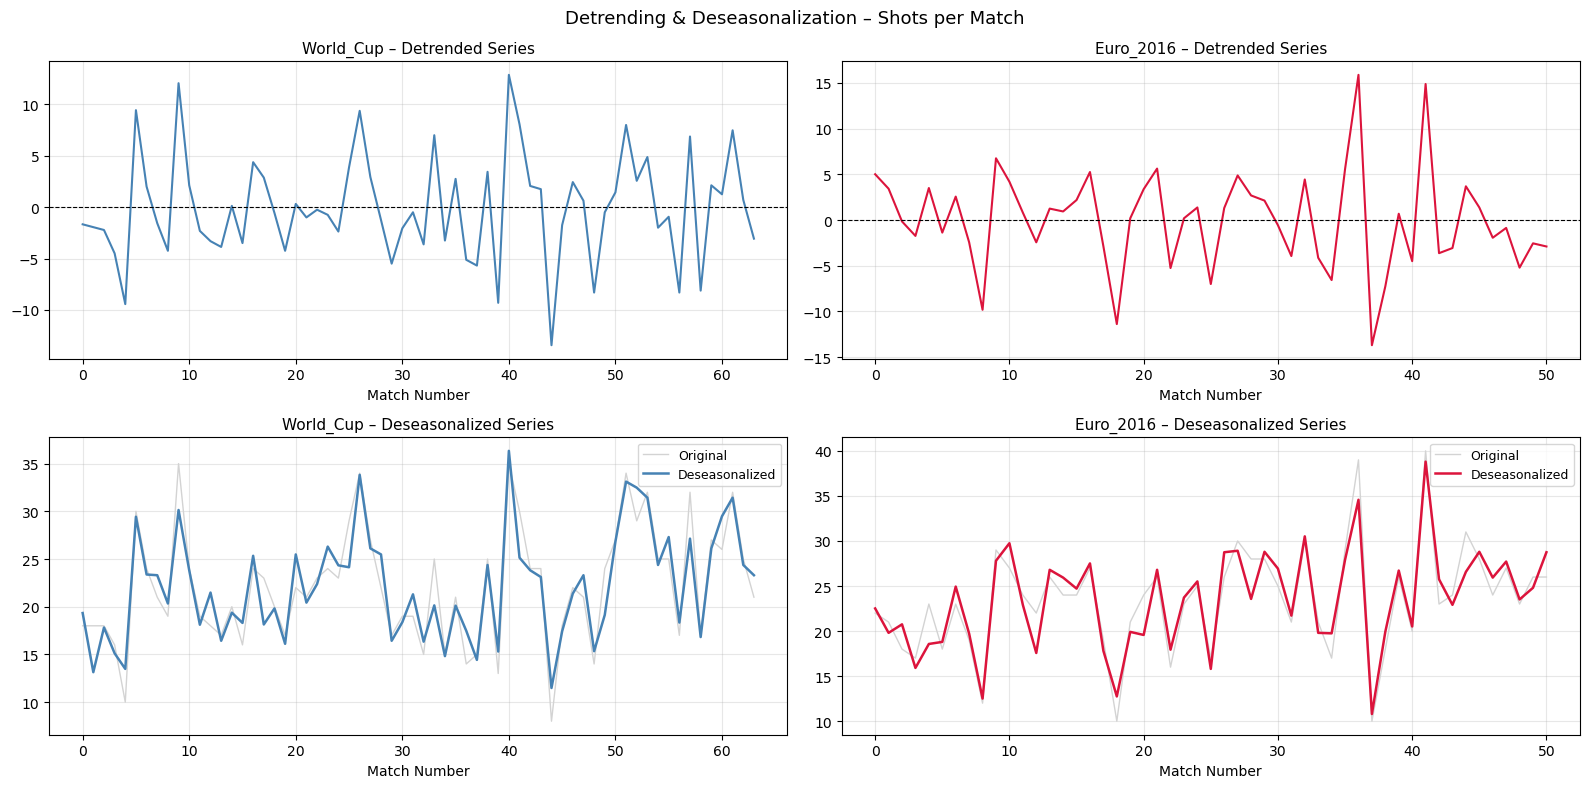

In [11]:
# ── 5c: Detrending & Deseasonalization ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col, name in enumerate(TOURNAMENTS.keys()):
    y = series[name].astype(float)
    decomp = decomps[name]
    color = COLORS[name]

    # Detrended
    detrended = y - decomp.trend
    axes[0][col].plot(detrended, color=color, linewidth=1.5)
    axes[0][col].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[0][col].set_title(f'{name} – Detrended Series', fontsize=11)
    axes[0][col].set_xlabel('Match Number')
    axes[0][col].grid(alpha=0.3)

    # Deseasonalized
    deseasoned = y - decomp.seasonal
    axes[1][col].plot(y, color='lightgray', linewidth=1, label='Original')
    axes[1][col].plot(deseasoned, color=color, linewidth=1.8, label='Deseasonalized')
    axes[1][col].set_title(f'{name} – Deseasonalized Series', fontsize=11)
    axes[1][col].set_xlabel('Match Number')
    axes[1][col].legend(fontsize=9)
    axes[1][col].grid(alpha=0.3)

plt.suptitle('Detrending & Deseasonalization – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()


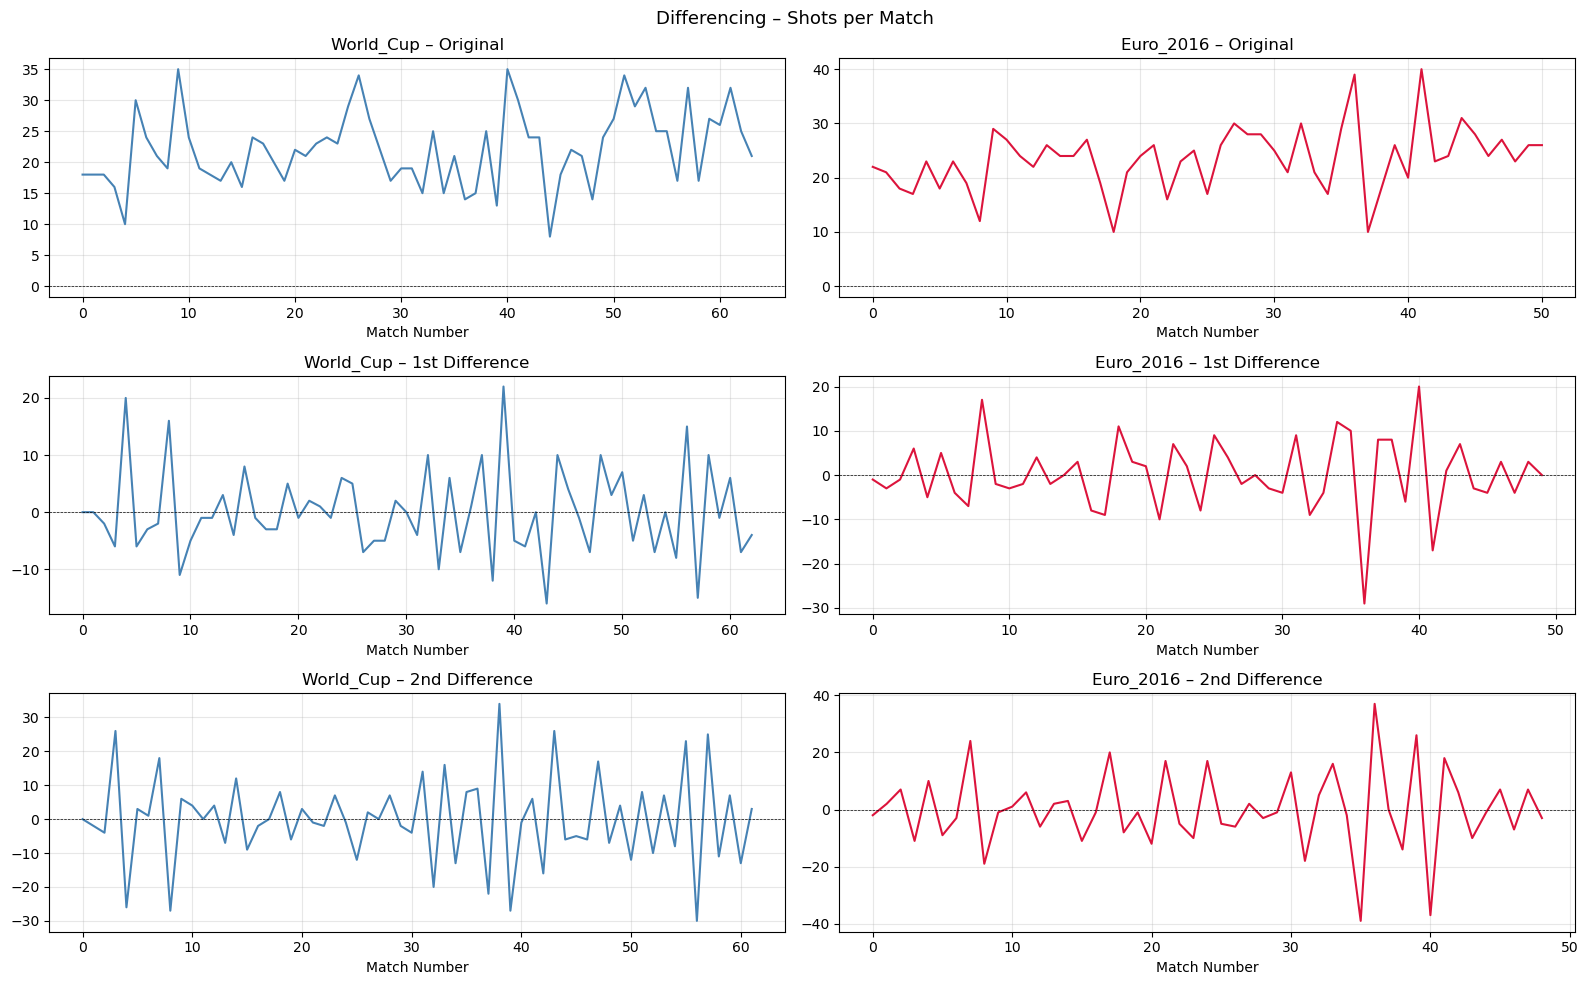

In [12]:
# ── 5d: Differencing ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for col, name in enumerate(TOURNAMENTS.keys()):
    y = series[name].astype(float)
    d1 = np.diff(y, n=1)
    d2 = np.diff(y, n=2)
    color = COLORS[name]

    axes[0][col].plot(y,  color=color);      axes[0][col].set_title(f'{name} – Original')
    axes[1][col].plot(d1, color=color);      axes[1][col].set_title(f'{name} – 1st Difference')
    axes[2][col].plot(d2, color=color);      axes[2][col].set_title(f'{name} – 2nd Difference')
    for ax in [axes[0][col], axes[1][col], axes[2][col]]:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
        ax.grid(alpha=0.3)
        ax.set_xlabel('Match Number')

plt.suptitle('Differencing – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()


---
## BLOCK 6: Task 2 – Temporal Autocorrelation & Stationarity

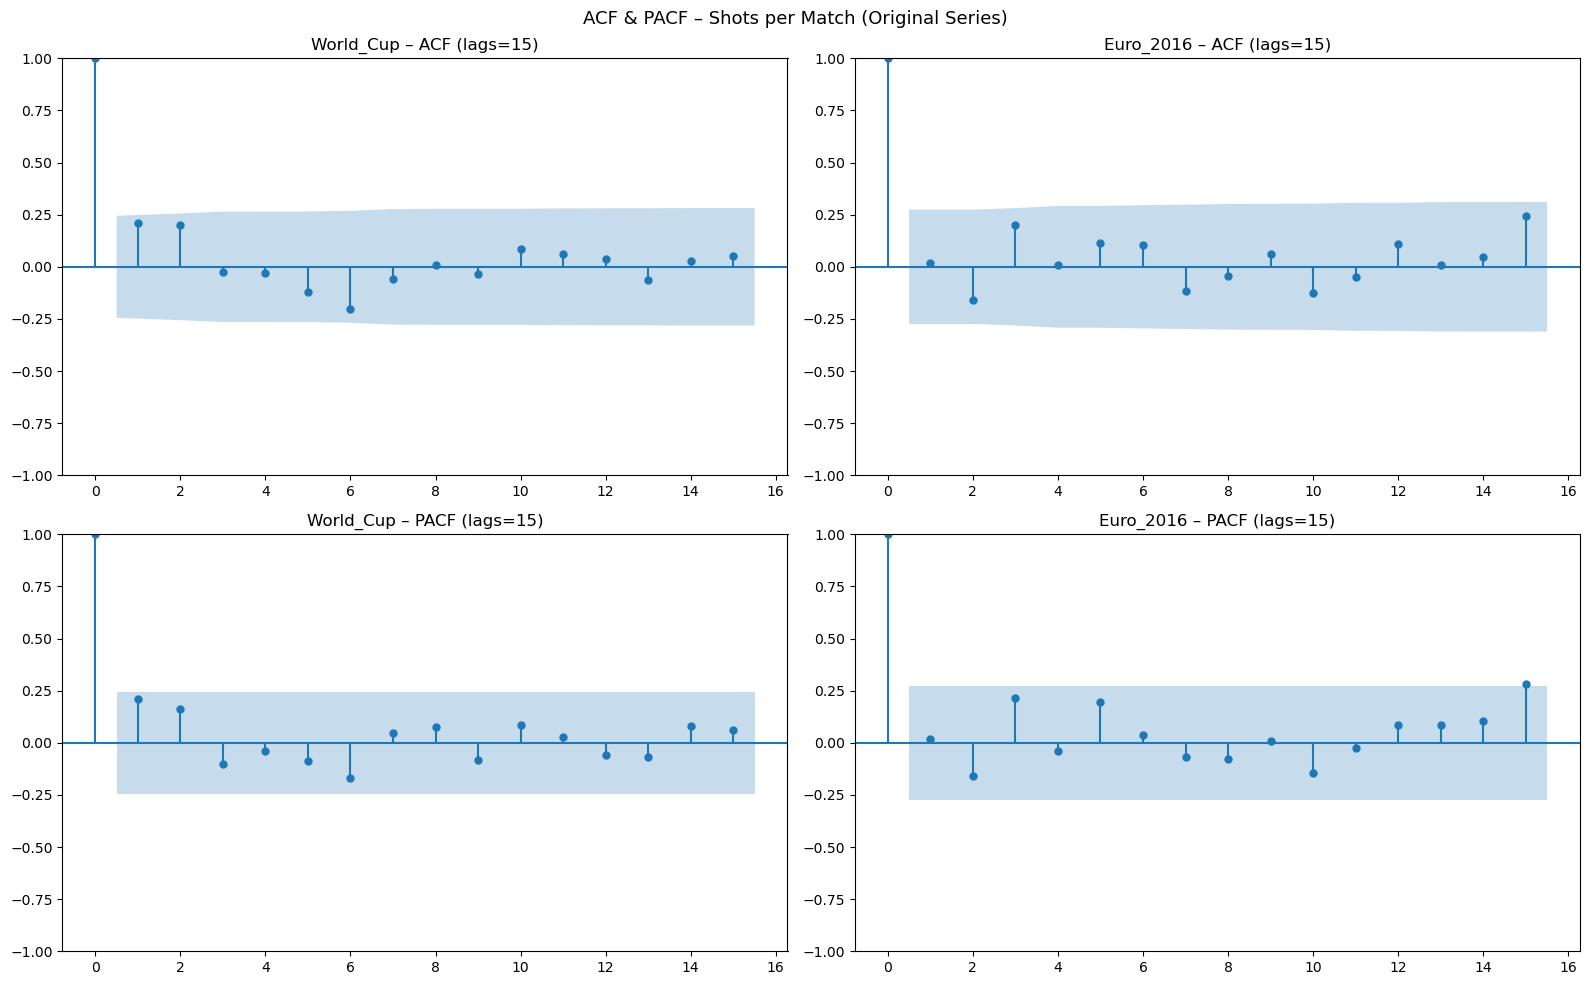

In [13]:
# ── 6a: ACF & PACF – both tournaments ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, name in enumerate(TOURNAMENTS.keys()):
    y = series[name]
    safe_lags = min(15, len(y) // 2 - 1)
    plot_acf(y,  lags=safe_lags, ax=axes[0][col],
             title=f'{name} – ACF (lags={safe_lags})')
    plot_pacf(y, lags=safe_lags, ax=axes[1][col],
              title=f'{name} – PACF (lags={safe_lags})')

plt.suptitle('ACF & PACF – Shots per Match (Original Series)', fontsize=13)
plt.tight_layout()
plt.show()


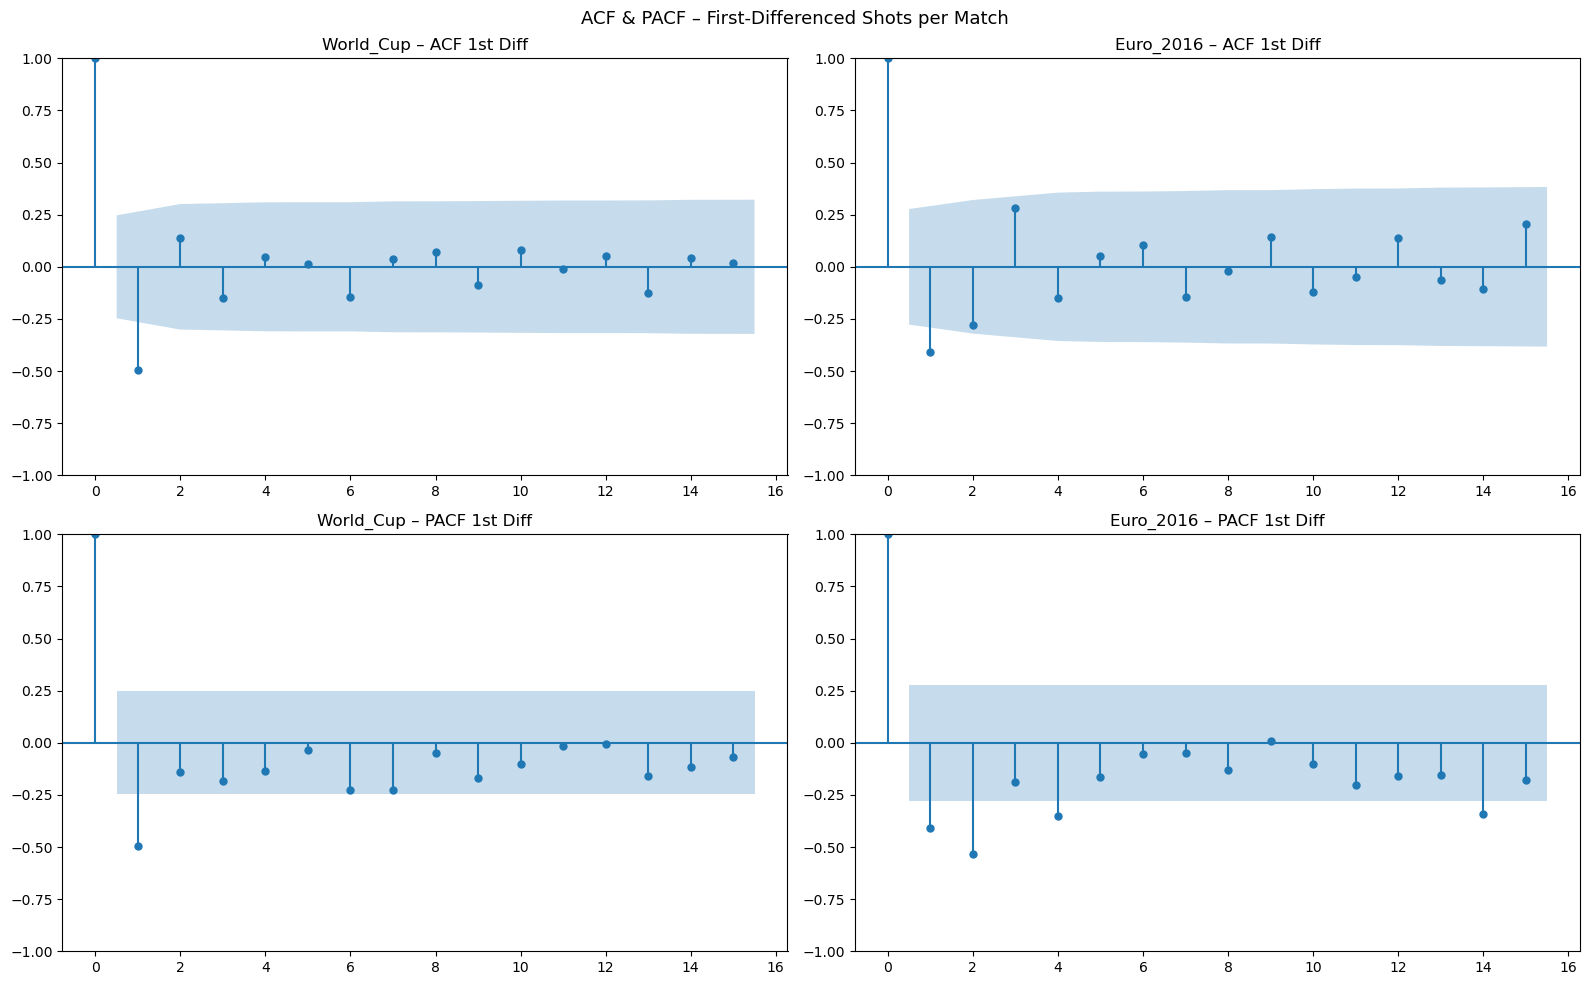

In [14]:
# ── 6b: ACF & PACF on differenced series ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, name in enumerate(TOURNAMENTS.keys()):
    y_d1 = np.diff(series[name].astype(float), n=1)
    safe_lags = min(15, len(y_d1) // 2 - 1)
    plot_acf(y_d1,  lags=safe_lags, ax=axes[0][col],
             title=f'{name} – ACF 1st Diff')
    plot_pacf(y_d1, lags=safe_lags, ax=axes[1][col],
              title=f'{name} – PACF 1st Diff')

plt.suptitle('ACF & PACF – First-Differenced Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()


In [15]:
# ── 6c: ADF & KPSS Stationarity Tests ────────────────────────────────────────
print('=== Stationarity Tests – Shots per Match ===')
print()

stat_rows = []
for name in TOURNAMENTS:
    y = series[name].astype(float)
    y_d1 = np.diff(y, n=1)

    for label, s in [('Original', y), ('1st Diff', y_d1)]:
        adf   = adfuller(s)
        kpss_ = kpss(s, regression='c', nlags='auto')
        acf_1 = acf(s, nlags=1)[1]
        stat_rows.append({
            'Tournament': name, 'Series': label,
            'Length': len(s),
            'Mean': round(s.mean(), 2),
            'Std': round(s.std(), 2),
            'ADF_p': round(adf[1], 4),
            'KPSS_p': round(kpss_[1], 4),
            'ACF_lag1': round(acf_1, 4),
            'ADF_Result': 'Stationary' if adf[1] < 0.05 else 'Non-Stationary',
        })

stat_df = pd.DataFrame(stat_rows)
print(stat_df.to_string(index=False))


=== Stationarity Tests – Shots per Match ===

Tournament   Series  Length  Mean  Std  ADF_p  KPSS_p  ACF_lag1 ADF_Result
 World_Cup Original      64 22.17 6.05 0.0008  0.1000    0.2121 Stationary
 World_Cup 1st Diff      63  0.05 7.63 0.0000  0.1000   -0.4940 Stationary
 Euro_2016 Original      51 23.47 5.79 0.0000  0.0248    0.0190 Stationary
 Euro_2016 1st Diff      50  0.08 8.18 0.0000  0.1000   -0.4098 Stationary


C:\Users\Rajdeep\AppData\Local\Temp\ipykernel_23120\3319485695.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(s, regression='c', nlags='auto')
C:\Users\Rajdeep\AppData\Local\Temp\ipykernel_23120\3319485695.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(s, regression='c', nlags='auto')
C:\Users\Rajdeep\AppData\Local\Temp\ipykernel_23120\3319485695.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(s, regression='c', nlags='auto')


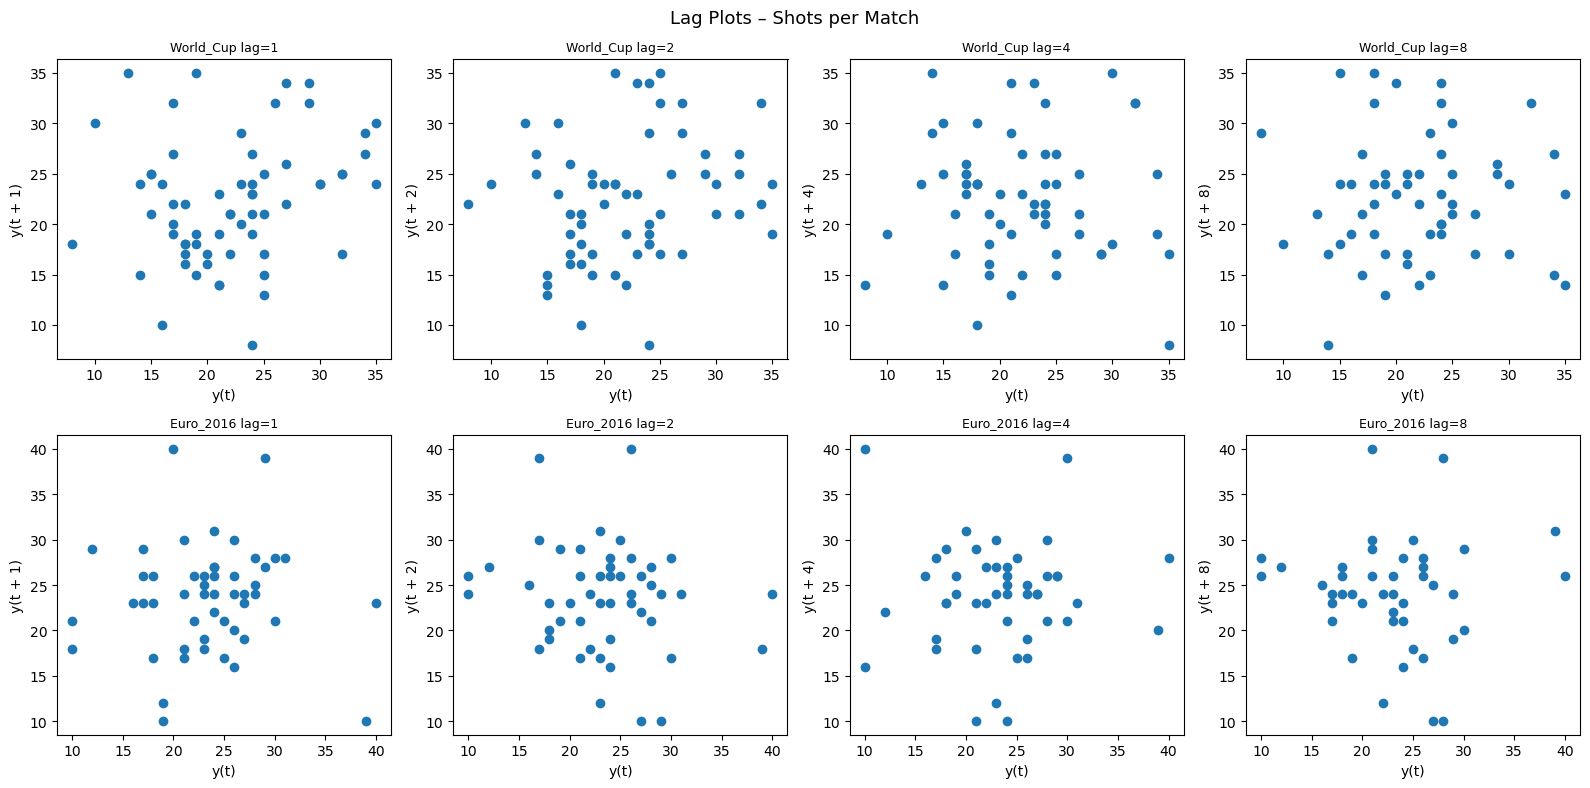

Diagonal pattern = positive autocorrelation at that lag.


In [16]:
# ── 6d: Lag plots ────────────────────────────────────────────────────────────
from pandas.plotting import lag_plot

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, name in enumerate(TOURNAMENTS.keys()):
    y = pd.Series(series[name])
    for col, lag in enumerate([1, 2, 4, 8]):
        lag_plot(y, lag=lag, ax=axes[row][col])
        axes[row][col].set_title(f'{name} lag={lag}', fontsize=9)

plt.suptitle('Lag Plots – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()
print('Diagonal pattern = positive autocorrelation at that lag.')


---
## BLOCK 7: Task 3 – Forecasting Models
### Sub-task A: Linear Regression Models

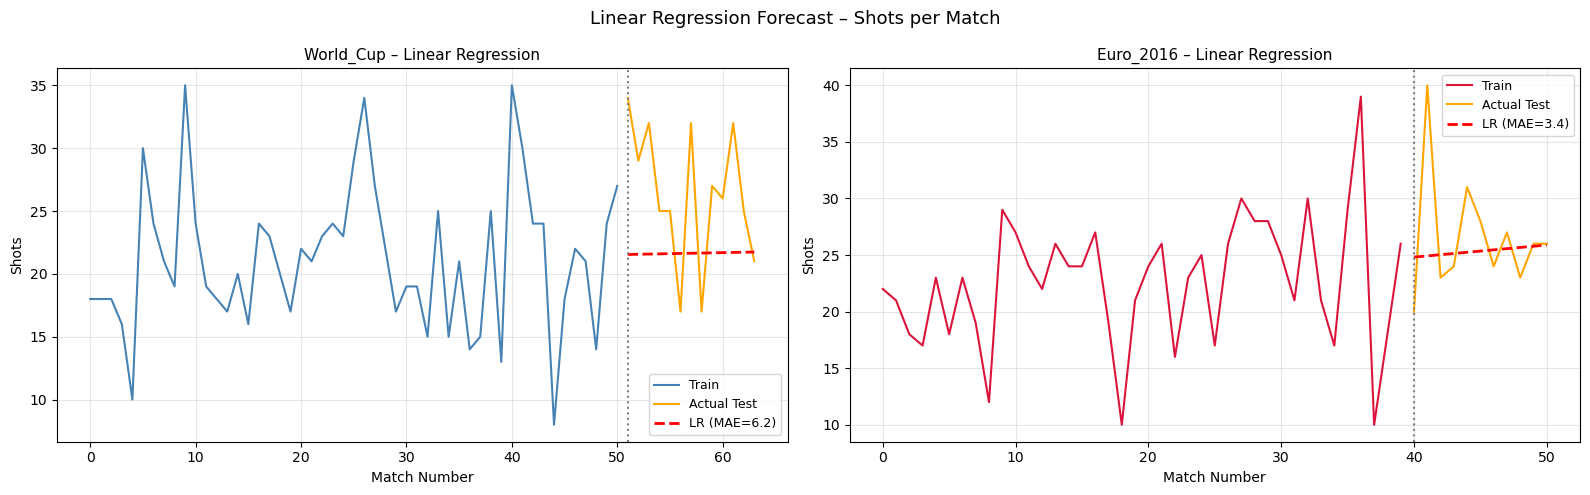

In [17]:
# ── 7a: Simple Linear Regression ─────────────────────────────────────────────
lr_results = []
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name in zip(axes, TOURNAMENTS.keys()):
    y = series[name].astype(float)
    X = np.arange(len(y)).reshape(-1,1)
    split = int(len(y) * 0.8)
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    lr = LinearRegression().fit(X_tr, y_tr)
    pred = lr.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    lr_results.append({'Tournament': name, 'Model': 'Linear', 'MAE': round(mae,2), 'RMSE': round(rmse,2)})

    ax.plot(range(split), y_tr, color=COLORS[name], label='Train')
    ax.plot(range(split, len(y)), y_te, color='orange', label='Actual Test')
    ax.plot(range(split, len(y)), pred, 'r--', linewidth=2, label=f'LR (MAE={mae:.1f})')
    ax.axvline(split, color='gray', linestyle=':')
    ax.set_title(f'{name} – Linear Regression', fontsize=11)
    ax.set_xlabel('Match Number')
    ax.set_ylabel('Shots')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Linear Regression Forecast – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()


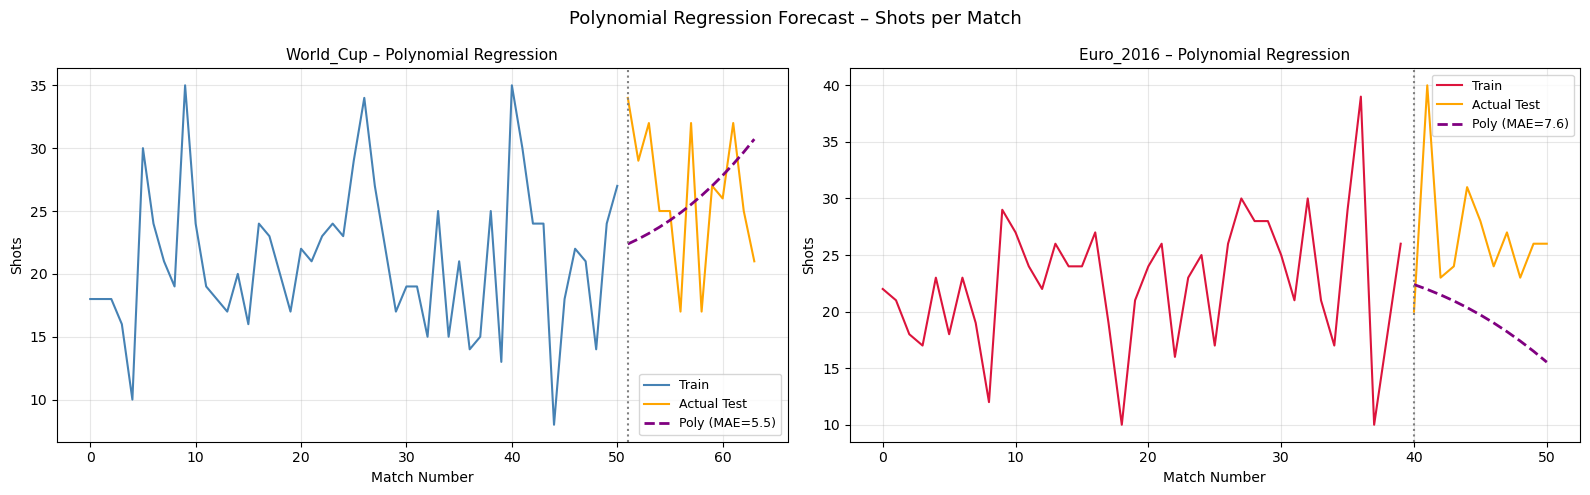

In [18]:
# ── 7b: Polynomial Regression (degree 3) ─────────────────────────────────────
poly_results = []
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name in zip(axes, TOURNAMENTS.keys()):
    y = series[name].astype(float)
    X = np.arange(len(y)).reshape(-1,1)
    split = int(len(y) * 0.8)
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    poly = PolynomialFeatures(degree=3)
    pr = LinearRegression().fit(poly.fit_transform(X_tr), y_tr)
    pred = pr.predict(poly.transform(X_te))
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    poly_results.append({'Tournament': name, 'Model': 'Polynomial(d=3)', 'MAE': round(mae,2), 'RMSE': round(rmse,2)})

    ax.plot(range(split), y_tr, color=COLORS[name], label='Train')
    ax.plot(range(split, len(y)), y_te, color='orange', label='Actual Test')
    ax.plot(range(split, len(y)), pred, 'purple', linestyle='--', linewidth=2,
            label=f'Poly (MAE={mae:.1f})')
    ax.axvline(split, color='gray', linestyle=':')
    ax.set_title(f'{name} – Polynomial Regression', fontsize=11)
    ax.set_xlabel('Match Number')
    ax.set_ylabel('Shots')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Polynomial Regression Forecast – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# ── 7c: Multi-feature Linear Regression ──────────────────────────────────────
multi_results = []
features = ['match_idx', 'passes', 'duels', 'total_goals']

for name in TOURNAMENTS:
    ms = match_series[name]
    X = ms[features].values
    y = ms['shots'].values
    split = int(len(y) * 0.8)
    mlr = LinearRegression().fit(X[:split], y[:split])
    pred = mlr.predict(X[split:])
    mae  = mean_absolute_error(y[split:], pred)
    rmse = np.sqrt(mean_squared_error(y[split:], pred))
    multi_results.append({'Tournament': name, 'Model': 'Multi-feature LR',
                          'MAE': round(mae,2), 'RMSE': round(rmse,2)})
    print(f'{name} Multi-LR → MAE: {mae:.2f} | Coefficients: {dict(zip(features, mlr.coef_.round(3)))}')


World_Cup Multi-LR → MAE: 5.96 | Coefficients: {'match_idx': np.float64(0.016), 'passes': np.float64(0.003), 'duels': np.float64(0.011), 'total_goals': np.float64(0.196)}
Euro_2016 Multi-LR → MAE: 4.59 | Coefficients: {'match_idx': np.float64(0.095), 'passes': np.float64(0.015), 'duels': np.float64(-0.015), 'total_goals': np.float64(0.921)}


### Sub-task B: ARIMA Models

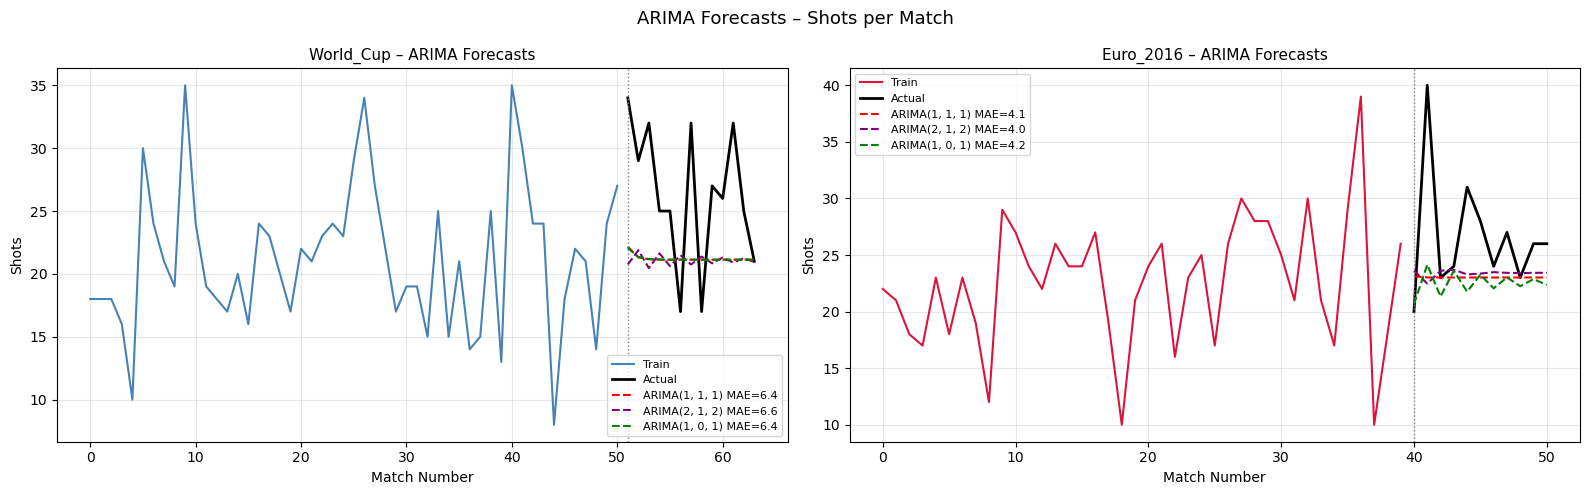


=== ARIMA Results ===
Tournament          Model  MAE  RMSE    AIC
 World_Cup ARIMA(1, 1, 1) 6.37  7.29 326.29
 World_Cup ARIMA(2, 1, 2) 6.58  7.61 328.97
 World_Cup ARIMA(1, 0, 1) 6.38  7.30 330.02
 Euro_2016 ARIMA(1, 1, 1) 4.09  6.20 256.70
 Euro_2016 ARIMA(2, 1, 2) 4.00  6.24 255.51
 Euro_2016 ARIMA(1, 0, 1) 4.18  6.07 258.03


In [20]:
# ── 7d: ARIMA models – both tournaments ──────────────────────────────────────
arima_orders = [(1,1,1), (2,1,2), (1,0,1)]
arima_results = []

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name in zip(axes, TOURNAMENTS.keys()):
    y = series[name].astype(float)
    split = int(len(y) * 0.8)
    y_tr, y_te = y[:split], y[split:]

    ax.plot(range(split), y_tr, color=COLORS[name], linewidth=1.5, label='Train')
    ax.plot(range(split, len(y)), y_te, color='black', linewidth=2, label='Actual')

    fc_colors = ['red','purple','green']
    for order, fc_color in zip(arima_orders, fc_colors):
        try:
            fit = ARIMA(y_tr, order=order).fit()
            fc  = fit.forecast(steps=len(y_te))
            mae  = mean_absolute_error(y_te, fc)
            rmse = np.sqrt(mean_squared_error(y_te, fc))
            arima_results.append({
                'Tournament': name,
                'Model': f'ARIMA{order}',
                'MAE': round(mae,2),
                'RMSE': round(rmse,2),
                'AIC': round(fit.aic,2)
            })
            ax.plot(range(split, len(y)), fc, color=fc_color,
                    linestyle='--', linewidth=1.5,
                    label=f'ARIMA{order} MAE={mae:.1f}')
        except Exception as e:
            print(f'{name} ARIMA{order} failed: {e}')

    ax.axvline(split, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{name} – ARIMA Forecasts', fontsize=11)
    ax.set_xlabel('Match Number')
    ax.set_ylabel('Shots')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ARIMA Forecasts – Shots per Match', fontsize=13)
plt.tight_layout()
plt.show()

arima_df = pd.DataFrame(arima_results)
print('\n=== ARIMA Results ===')
print(arima_df.to_string(index=False))


In [21]:
# ── 7e: SARIMA ────────────────────────────────────────────────────────────────
sarima_results = []
for name in TOURNAMENTS:
    y = series[name].astype(float)
    split = int(len(y) * 0.8)
    y_tr, y_te = y[:split], y[split:]
    try:
        fit = SARIMAX(y_tr, order=(1,1,1), seasonal_order=(1,0,1,8)).fit(disp=False)
        fc  = fit.forecast(steps=len(y_te))
        mae  = mean_absolute_error(y_te, fc)
        rmse = np.sqrt(mean_squared_error(y_te, fc))
        sarima_results.append({'Tournament': name, 'Model': 'SARIMA(1,1,1)(1,0,1,8)',
                                'MAE': round(mae,2), 'RMSE': round(rmse,2), 'AIC': round(fit.aic,2)})
        print(f'{name} SARIMA → MAE={mae:.2f} | RMSE={rmse:.2f} | AIC={fit.aic:.2f}')
    except Exception as e:
        print(f'{name} SARIMA failed: {e}')


World_Cup SARIMA → MAE=6.45 | RMSE=7.31 | AIC=329.96
Euro_2016 SARIMA → MAE=4.56 | RMSE=6.49 | AIC=258.39


c:\Users\Rajdeep\anaconda3\envs\spatial_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## BLOCK 8: Residual Diagnostics

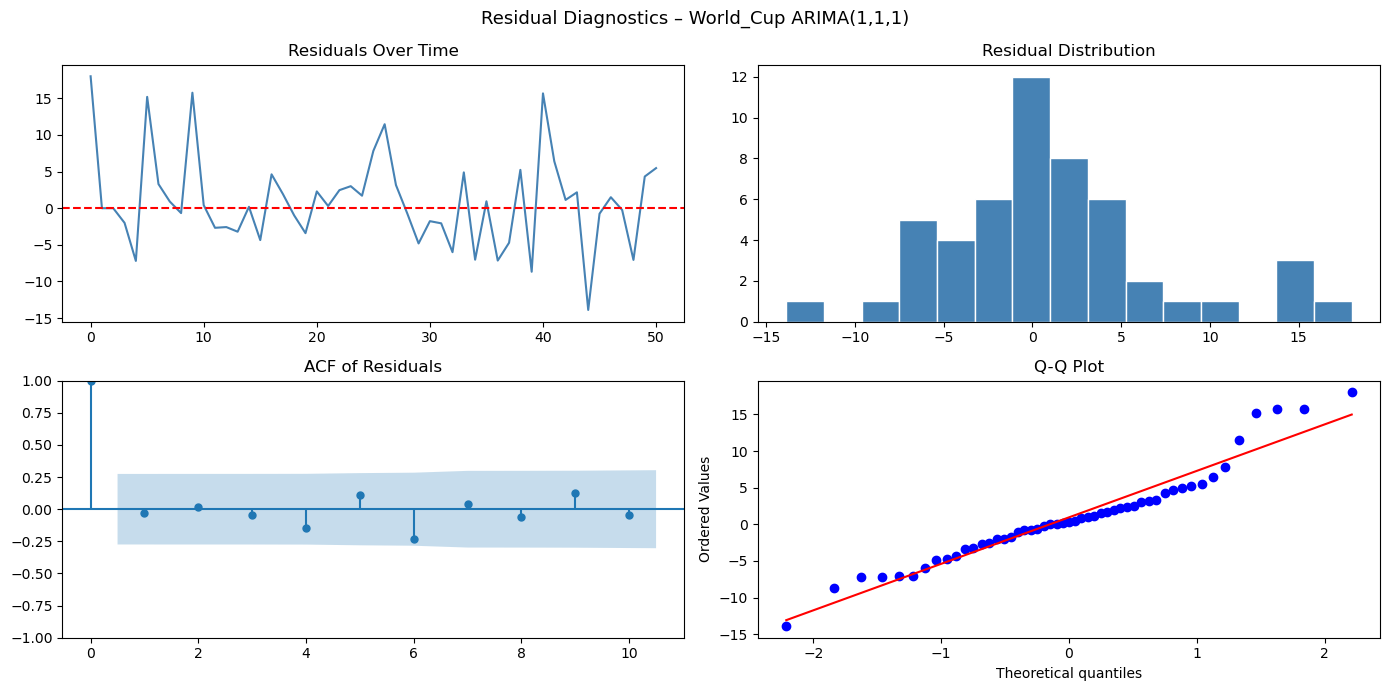

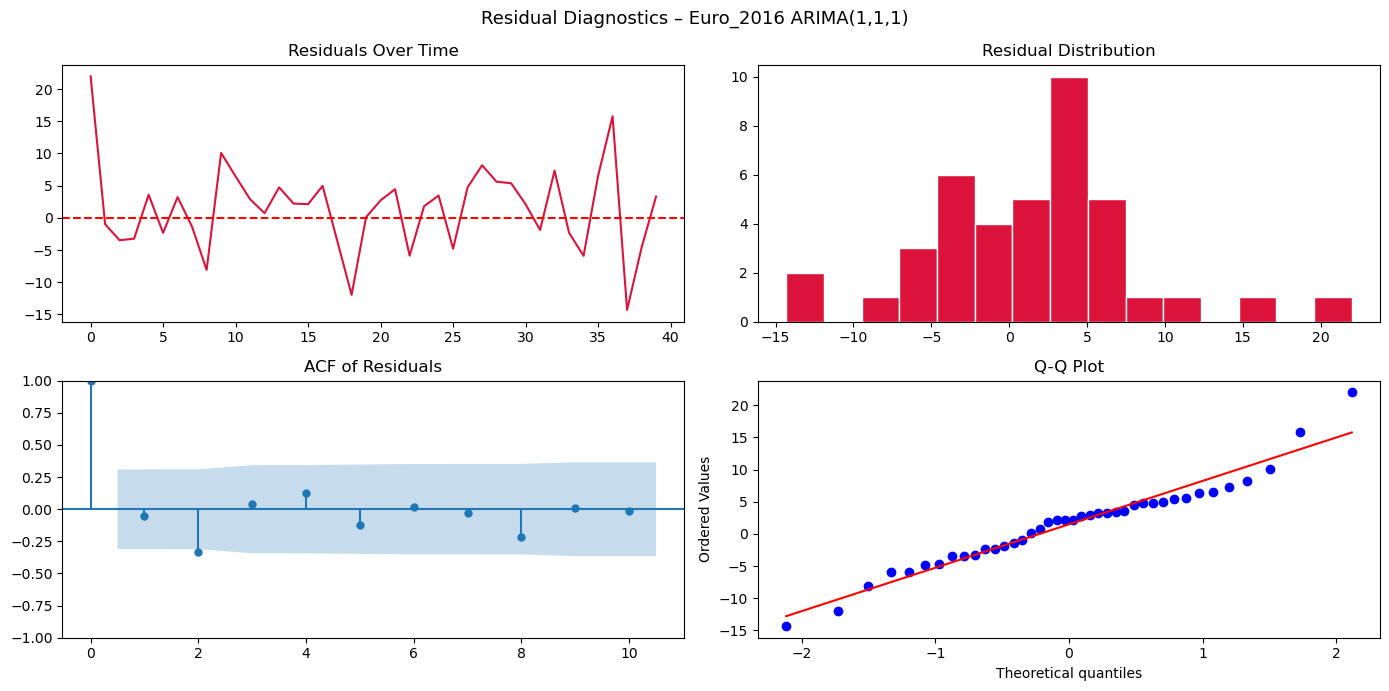

In [22]:
# ── 8a: Residual diagnostics for best ARIMA per tournament ───────────────────
for name in TOURNAMENTS:
    y = series[name].astype(float)
    split = int(len(y) * 0.8)
    fit = ARIMA(y[:split], order=(1,1,1)).fit()
    resid = fit.resid

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes[0,0].plot(resid, color=COLORS[name])
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title('Residuals Over Time')

    axes[0,1].hist(resid, bins=15, color=COLORS[name], edgecolor='white')
    axes[0,1].set_title('Residual Distribution')

    safe_lags = min(10, len(resid) // 2 - 1)
    plot_acf(resid, lags=safe_lags, ax=axes[1,0], title='ACF of Residuals')

    stats.probplot(resid, plot=axes[1,1])
    axes[1,1].set_title('Q-Q Plot')

    plt.suptitle(f'Residual Diagnostics – {name} ARIMA(1,1,1)', fontsize=13)
    plt.tight_layout()
    plt.show()


---
## BLOCK 9: Final Comparison Summary

In [23]:
# ── 9a: All model results combined ───────────────────────────────────────────
all_model_results = pd.DataFrame(
    lr_results + poly_results + multi_results +
    arima_results + (sarima_results if sarima_results else [])
)
all_model_results['AIC'] = all_model_results.get('AIC', '-')

print('=== Complete Model Comparison – World Cup vs Euro ===')
for name in TOURNAMENTS:
    print(f'\n{name}:')
    sub = all_model_results[all_model_results['Tournament']==name]
    print(sub[['Model','MAE','RMSE']].to_string(index=False))


=== Complete Model Comparison – World Cup vs Euro ===

World_Cup:
                 Model  MAE  RMSE
                Linear 6.21  7.11
       Polynomial(d=3) 5.52  6.64
      Multi-feature LR 5.96  6.72
        ARIMA(1, 1, 1) 6.37  7.29
        ARIMA(2, 1, 2) 6.58  7.61
        ARIMA(1, 0, 1) 6.38  7.30
SARIMA(1,1,1)(1,0,1,8) 6.45  7.31

Euro_2016:
                 Model  MAE  RMSE
                Linear 3.40  5.29
       Polynomial(d=3) 7.57  8.83
      Multi-feature LR 4.59  5.83
        ARIMA(1, 1, 1) 4.09  6.20
        ARIMA(2, 1, 2) 4.00  6.24
        ARIMA(1, 0, 1) 4.18  6.07
SARIMA(1,1,1)(1,0,1,8) 4.56  6.49


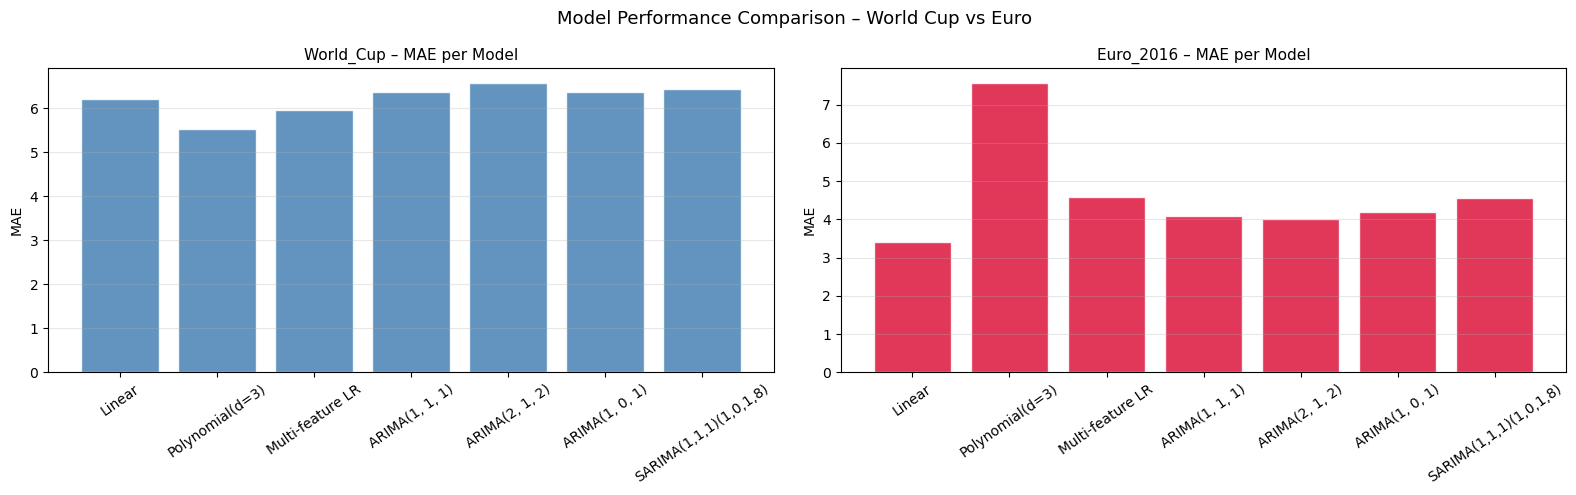

In [24]:
# ── 9b: MAE comparison bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, name in zip(axes, TOURNAMENTS.keys()):
    sub = all_model_results[all_model_results['Tournament']==name].copy()
    sub['MAE'] = pd.to_numeric(sub['MAE'], errors='coerce')
    sub = sub.dropna(subset=['MAE'])
    ax.bar(sub['Model'], sub['MAE'],
           color=COLORS[name], edgecolor='white', alpha=0.85)
    ax.set_title(f'{name} – MAE per Model', fontsize=11)
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Model Performance Comparison – World Cup vs Euro', fontsize=13)
plt.tight_layout()
plt.show()


In [25]:
# ── 9c: Final printed summary ─────────────────────────────────────────────────
print('=' * 60)
print('   TOURNAMENT TEMPORAL ANALYSIS – FINAL SUMMARY')
print('=' * 60)
for name in TOURNAMENTS:
    ms = match_series[name]
    y  = series[name]
    adf_p = adfuller(y)[1]
    print(f'\n{name}')
    print(f'  Matches          : {len(ms)}')
    print(f'  Avg shots/match  : {ms["shots"].mean():.1f}')
    print(f'  Avg goals/match  : {ms["total_goals"].mean():.2f}')
    print(f'  Avg passes/match : {ms["passes"].mean():.1f}')
    print(f'  ADF p-value      : {adf_p:.4f} ({"Stationary" if adf_p<0.05 else "Non-Stationary"})')

print()
print('── Best Models ──────────────────────────────────────────')
for name in TOURNAMENTS:
    sub = all_model_results[all_model_results['Tournament']==name].copy()
    sub['MAE'] = pd.to_numeric(sub['MAE'], errors='coerce')
    best = sub.loc[sub['MAE'].idxmin()]
    print(f'  {name}: Best = {best["Model"]} (MAE={best["MAE"]})')
print('=' * 60)


   TOURNAMENT TEMPORAL ANALYSIS – FINAL SUMMARY

World_Cup
  Matches          : 64
  Avg shots/match  : 22.2
  Avg goals/match  : 2.59
  Avg passes/match : 882.1
  ADF p-value      : 0.0008 (Stationary)

Euro_2016
  Matches          : 51
  Avg shots/match  : 23.5
  Avg goals/match  : 2.08
  Avg passes/match : 856.7
  ADF p-value      : 0.0000 (Stationary)

── Best Models ──────────────────────────────────────────
  World_Cup: Best = Polynomial(d=3) (MAE=5.52)
  Euro_2016: Best = Linear (MAE=3.4)
